# Bloch2D — Bands in a square cosine potential

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>
> Accepted local contract: `docs/harness/physkit.harness.09-dimensional-periodic-solids-notebook-series-contract.md`  
> Accepted contract SHA-256: `97736dc9bb9a5fcd3561b51fea8b2869ecbe1bbb4d1a8b7b2df9d0b4313b9ce9`

## Question

How do separable periodic directions form two-dimensional Bloch bands?

## Learning objectives

- Construct the square-cell Hamiltonian as a Kronecker sum.
- Use separability as an independent low-spectrum reference.
- Follow energy-ordered bands along $\Gamma-X-M-\Gamma$.
- State what a high-symmetry path does and does not sample.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This extends Bloch1D to a square cell while retaining the orthogonal-cell restriction.


## Square-cell model

$$
H_{\mathbf k}=-(\nabla+i\mathbf k)^2
+V_0[\cos(2\pi x/L)+\cos(2\pi y/L)].
$$

The potential is separable, so the finite Hamiltonian is a Kronecker sum. Its
eigenvalues are pairwise sums of the corresponding 1D eigenvalues.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.linalg import eigvalsh
from scipy.sparse.linalg import eigsh


def bloch_kinetic_1d(n, length, k):
    h = length / n
    rows = np.repeat(np.arange(n), 3)
    columns = np.column_stack(((np.arange(n) - 1) % n,
                               np.arange(n),
                               (np.arange(n) + 1) % n)).ravel()
    values = np.column_stack((np.full(n, -np.exp(-1j * k * h) / h**2),
                              np.full(n, 2.0 / h**2),
                              np.full(n, -np.exp(1j * k * h) / h**2))).ravel()
    return sparse.coo_matrix((values, (rows, columns)), shape=(n, n)).tocsr()


def cosine_hamiltonian_1d(n, length, k, amplitude=1.0):
    x = np.arange(n) * length / n
    potential = amplitude * np.cos(2 * np.pi * x / length)
    return bloch_kinetic_1d(n, length, k) + sparse.diags(potential, format="csr"), x, potential


def hermiticity_error(matrix):
    difference = matrix - matrix.getH()
    return 0.0 if difference.nnz == 0 else np.max(np.abs(difference.data))


def low_1d_bands(n, length, q_value, count=6, amplitude=1.0):
    k = 2 * np.pi * q_value / length
    matrix, _, _ = cosine_hamiltonian_1d(n, length, k, amplitude)
    return eigvalsh(matrix.toarray(), subset_by_index=(0, min(count, n) - 1))

def piecewise_path(vertices, points_per_segment):
    points = [np.asarray(vertices[0], dtype=float)]
    ticks = [0]
    for start, stop in zip(vertices[:-1], vertices[1:]):
        segment = np.linspace(start, stop, points_per_segment, endpoint=True)[1:]
        points.extend(segment)
        ticks.append(len(points) - 1)
    return np.asarray(points), np.asarray(ticks)

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
N, L, V0 = 25, 1.0, 1.0
q_test = np.array([0.17, -0.13])
Hx, x, vx = cosine_hamiltonian_1d(N, L, 2 * np.pi * q_test[0] / L, V0)
Hy, y, vy = cosine_hamiltonian_1d(N, L, 2 * np.pi * q_test[1] / L, V0)
I = sparse.identity(N, format="csr")
H2 = sparse.kron(Hx, I, format="csr") + sparse.kron(I, Hy, format="csr")
assert H2.shape == (N * N, N * N)
assert np.issubdtype(H2.dtype, np.complexfloating)
assert hermiticity_error(H2) < 1e-12

reference = np.sort((low_1d_bands(N, L, q_test[0], count=8, amplitude=V0)[:, None]
                     + low_1d_bands(N, L, q_test[1], count=8, amplitude=V0)[None, :]).ravel())
eigenvalues, eigenvectors = eigsh(H2, k=6, which="SA", v0=np.ones(H2.shape[0]))
order = np.argsort(eigenvalues)
numeric, eigenvectors = eigenvalues[order], eigenvectors[:, order]
residuals = np.array([
    np.linalg.norm(H2 @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(numeric)
])
assert np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
h = L / N
G = 2 * np.pi * np.fft.fftfreq(N, d=h)
free_1d = [np.sort(4.0 / h**2 * np.sin(np.pi * (G * L / (2 * np.pi) + q) / N) ** 2)
           for q in q_test]
free_reference = np.sort((free_1d[0][:, None] + free_1d[1][None, :]).ravel())
free_numeric = np.sort((low_1d_bands(N, L, q_test[0], count=8, amplitude=0.0)[:, None]
                        + low_1d_bands(N, L, q_test[1], count=8, amplitude=0.0)[None, :]).ravel())
assert np.allclose(free_numeric[:6], free_reference[:6], rtol=1e-10, atol=1e-12)
print("Hamiltonian shape:", H2.shape, "nnz:", H2.nnz)
print("lowest full/reference eigenvalues:\n", np.column_stack([numeric, reference[:6]]))
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


Hamiltonian shape: (625, 625) nnz: 3125
lowest full/reference eigenvalues:
 [[ 1.779845  1.779845]
 [27.758874 27.758874]
 [30.894942 30.894942]
 [51.201503 51.201503]
 [54.310003 54.310003]
 [56.873972 56.873972]]
eigensolver residual bound satisfied: True


In [3]:
vertices = np.array([[0.0, 0.0], [0.5, 0.0], [0.5, 0.5], [0.0, 0.0]])
labels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
q_path, ticks = piecewise_path(vertices, points_per_segment=41)
assert np.allclose(q_path[ticks], vertices, rtol=1e-10, atol=1e-12)
bands = []
for qx, qy in q_path:
    ex = low_1d_bands(N, L, qx, count=6, amplitude=V0)
    ey = low_1d_bands(N, L, qy, count=6, amplitude=V0)
    bands.append(np.sort((ex[:, None] + ey[None, :]).ravel())[:6])
bands = np.asarray(bands)
assert np.all(np.isfinite(bands))
assert np.all(np.diff(bands, axis=1) >= -1e-10)
assert np.allclose(bands[0], bands[-1], rtol=1e-10, atol=1e-12)
print("path points:", len(q_path), "band array shape:", bands.shape)


path points: 121 band array shape: (121, 6)


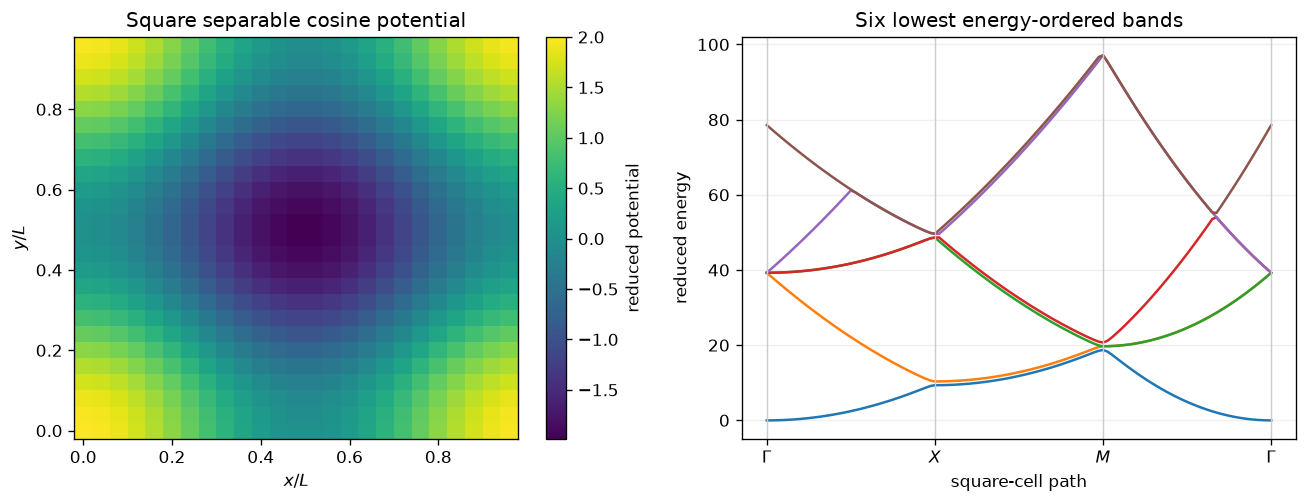

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
X, Y = np.meshgrid(x, y, indexing="ij")
potential = V0 * (np.cos(2 * np.pi * X / L) + np.cos(2 * np.pi * Y / L))
image = axes[0].pcolormesh(X / L, Y / L, potential, shading="auto", cmap="viridis")
axes[0].set(xlabel=r"$x/L$", ylabel=r"$y/L$", title="Square separable cosine potential")
fig.colorbar(image, ax=axes[0], label="reduced potential")
axes[1].plot(np.arange(len(q_path)), bands)
axes[1].set_xticks(ticks, labels)
axes[1].set(xlabel="square-cell path", ylabel="reduced energy", title="Six lowest energy-ordered bands")
for tick in ticks:
    axes[1].axvline(tick, color="0.8", linewidth=0.8)
axes[1].grid(alpha=0.2)
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The $\Gamma-X-M-\Gamma$ path samples selected lines, not the entire Brillouin zone. Separability is a special feature of the chosen synthetic potential.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

Bloch3D extends the same construction to a simple-cubic cell and bounded sparse checks.
